# Elevation Bias Analysis
Analyzing the relationship between elevation differences (Δz) and model errors

In [1]:
import json
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load station data and DEM elevation information

In [2]:
# Load SNOWPACK station metadata (contains true station elevations)
with open("../data/SNOWPACK/vstations.json", "r") as f:
    vstations = json.load(f)

# Load validation results with model errors
validation_df = pd.read_csv("../data/processed/validation_stations_with_coordinates.csv")

print(f"Loaded {len(validation_df)} validation stations")
print(f"\nColumns in validation data:")
print(validation_df.columns.tolist())

Loaded 11 validation stations

Columns in validation data:
['Station', 'Station_Code', 'N_Days', 'Period_Start', 'Period_End', 'FSM2_Bias', 'FSM2_RMSE', 'FSM2_Corr', 'seNorge_Bias', 'seNorge_RMSE', 'seNorge_Corr', 'SNOWPACK_Bias', 'SNOWPACK_RMSE', 'SNOWPACK_Corr', 'SNOWPACK_Station', 'SNOWPACK_Distance_m', 'lat', 'lon', 'easting', 'northing', 'geometry', 'mean_RMSE', 'best_model', 'worst_model', 'min_rmse', 'max_rmse', 'best_model_name', 'worst_model_name']


In [3]:
# Load DEM data to get model elevation at each grid point
# We'll use the FSM2 dataset as reference for model elevations
fsm2_2023 = xr.open_dataset("../data/FSM2/fsm2_sd_2023.nc")
senorge_2023 = xr.open_dataset("../data/seNorge/sd_2023.nc")

print("\nFSM2 dataset variables:")
print(fsm2_2023.data_vars)
print("\nFSM2 dataset coordinates:")
print(fsm2_2023.coords)

# Check if elevation is in the data
if 'elevation' in fsm2_2023.data_vars:
    print("\nElevation found in FSM2 data")
elif 'z' in fsm2_2023.data_vars:
    print("\nElevation 'z' found in FSM2 data")
else:
    print("\nNo elevation variable found, checking seNorge...")
    print(senorge_2023.data_vars)


FSM2 dataset variables:
Data variables:
    snow_depth   (time, y, x) float32 3GB ...
    UTM_Zone_33  float64 8B ...

FSM2 dataset coordinates:
Coordinates:
  * time     (time) datetime64[ns] 3kB 2023-01-01 2023-01-02 ... 2023-12-31
  * y        (y) float64 12kB 6.45e+06 6.451e+06 ... 7.998e+06 7.999e+06
  * x        (x) float64 10kB -7.5e+04 -7.4e+04 -7.3e+04 ... 1.118e+06 1.119e+06
    lon      (y, x) float64 15MB ...
    lat      (y, x) float64 15MB ...

No elevation variable found, checking seNorge...
Data variables:
    snow_depth   (time, y, x) float32 3GB ...
    UTM_Zone_33  float64 8B ...


## 2. Extract and compare SNOWPACK model elevations vs observation station elevations

In [9]:
# Known observation station elevations (from Meteorologisk Institutt)
# These are the actual elevation of the meteorological stations
obs_station_elevations = {
    'SN23550': 1033,    # Beitostølen Ii
    'SN15660': 820,     # Skjåk
    'SN55290': 1909,    # Sognefjellhytta
    'SN13750': 1092,    # Øvre Heimdalsvatn
    'SN15430': 1265,    # Bøverdal
    'SN15270': 1894,    # Juvvasshøe
    'SN13760': 1329,    # Fv51 Valdresflye
    'SN55300': 662,     # Skjolden
    'SN15890': 929,     # Grotli Iii
    'SN54815': 907,     # Fv53 Tyinosen
    'SN54710': 750      # Filefjell - Kyrkjestølane
}

elevation_data = []

for idx, row in validation_df.iterrows():
    station_name = row['Station']
    station_code = row['Station_Code']
    snowpack_station = row['SNOWPACK_Station']
    
    # Get observation station elevation
    obs_elev = obs_station_elevations.get(station_code, np.nan)
    
    # Get model (SNOWPACK grid cell) elevation
    if snowpack_station in vstations:
        model_elev = vstations[snowpack_station]['elev']
    else:
        model_elev = np.nan
    
    # Calculate elevation difference (Δz = obs_elevation - model_elevation)
    # Positive means observation station is higher than the model grid cell
    delta_z = obs_elev - model_elev if not np.isnan(obs_elev) and not np.isnan(model_elev) else np.nan
    
    elevation_data.append({
        'Station': station_name,
        'Station_Code': station_code,
        'Obs_Elevation': obs_elev,
        'Model_Elevation': model_elev,
        'SNOWPACK_Station': snowpack_station,
        'Delta_Z': delta_z,
        'Abs_Delta_Z': abs(delta_z) if not np.isnan(delta_z) else np.nan,
        'Latitude': row['lat'],
        'Longitude': row['lon'],
        'FSM2_Bias': row['FSM2_Bias'],
        'FSM2_RMSE': row['FSM2_RMSE'],
        'seNorge_Bias': row['seNorge_Bias'],
        'seNorge_RMSE': row['seNorge_RMSE'],
        'SNOWPACK_Bias': row['SNOWPACK_Bias'],
        'SNOWPACK_RMSE': row['SNOWPACK_RMSE'],
        'Mean_RMSE': row['mean_RMSE']
    })

elev_df = pd.DataFrame(elevation_data)
print(f"Created elevation comparison dataframe with {len(elev_df)} stations\n")
print("ELEVATION COMPARISON TABLE:")
print("="*80)
display_cols = ['Station', 'Obs_Elevation', 'Model_Elevation', 'Delta_Z', 'Abs_Delta_Z']
print(elev_df[display_cols].to_string(index=False))

print("\n\nELEVATION STATISTICS:")
print("="*80)
print(f"Observation Elevation (m):  Mean={elev_df['Obs_Elevation'].mean():.0f}, Min={elev_df['Obs_Elevation'].min():.0f}, Max={elev_df['Obs_Elevation'].max():.0f}")
print(f"Model Elevation (m):         Mean={elev_df['Model_Elevation'].mean():.0f}, Min={elev_df['Model_Elevation'].min():.0f}, Max={elev_df['Model_Elevation'].max():.0f}")
print(f"\nElevation Difference Δz (m): Mean={elev_df['Delta_Z'].mean():.1f}, Min={elev_df['Delta_Z'].min():.1f}, Max={elev_df['Delta_Z'].max():.1f}")
print(f"|Δz| (m):                    Mean={elev_df['Abs_Delta_Z'].mean():.1f}, Median={elev_df['Abs_Delta_Z'].median():.1f}, Max={elev_df['Abs_Delta_Z'].max():.1f}")
print(f"\nStations with |Δz| > 100m:   {len(elev_df[elev_df['Abs_Delta_Z'] > 100])}")

Created elevation comparison dataframe with 11 stations

ELEVATION COMPARISON TABLE:
                  Station  Obs_Elevation  Model_Elevation  Delta_Z  Abs_Delta_Z
           Beitostølen Ii           1033           1410.0   -377.0        377.0
                    Skjåk            820           1410.0   -590.0        590.0
          Sognefjellhytta           1909           1410.0    499.0        499.0
        Øvre Heimdalsvatn           1092           1410.0   -318.0        318.0
                 Bøverdal           1265           1410.0   -145.0        145.0
               Juvvasshøe           1894           1410.0    484.0        484.0
         Fv51 Valdresflye           1329           1410.0    -81.0         81.0
                 Skjolden            662           1410.0   -748.0        748.0
               Grotli Iii            929           1410.0   -481.0        481.0
            Fv53 Tyinosen            907           1410.0   -503.0        503.0
Filefjell - Kyrkjestølane          

## 3. Save elevation bias analysis to CSV

In [10]:
# Save to CSV
output_path = "../data/processed/elevation_analysis.csv"
elev_df.to_csv(output_path, index=False)
print(f"Saved elevation analysis to: {output_path}")

Saved elevation analysis to: ../data/processed/elevation_analysis.csv


## 4. Correlation Analysis: Δz vs Model Errors

In [12]:
# Correlation Analysis: Station Elevation vs Model Errors
# Higher elevation stations might have different error characteristics

valid_data = elev_df.dropna(subset=['Obs_Elevation', 'Model_Elevation', 'Delta_Z', 'FSM2_RMSE', 'seNorge_RMSE', 'SNOWPACK_RMSE'])

print(f"Valid data for correlation analysis: {len(valid_data)} stations")
print(f"\n{'='*60}")
print("CORRELATION ANALYSIS: |Δz| (Elevation Bias) vs Model RMSE")
print(f"{'='*60}\n")

models = ['FSM2', 'seNorge', 'SNOWPACK']
correlations = {}

for model in models:
    rmse_col = f'{model}_RMSE'
    
    # Pearson correlation
    corr, p_value = stats.pearsonr(valid_data['Abs_Delta_Z'], valid_data[rmse_col])
    # Spearman correlation (rank-based)
    spearman_corr, spearman_p = stats.spearmanr(valid_data['Abs_Delta_Z'], valid_data[rmse_col])
    
    correlations[model] = {
        'Pearson_r': corr,
        'Pearson_p': p_value,
        'Spearman_rho': spearman_corr,
        'Spearman_p': spearman_p
    }
    
    print(f"{model}:")
    print(f"  Pearson r = {corr:.4f}, p-value = {p_value:.4f}")
    print(f"  Spearman ρ = {spearman_corr:.4f}, p-value = {spearman_p:.4f}")
    if p_value < 0.05:
        print(f"  ✓ SIGNIFICANT correlation at p < 0.05")
    else:
        print(f"  ✗ No significant correlation")
    print()

Valid data for correlation analysis: 11 stations

CORRELATION ANALYSIS: |Δz| (Elevation Bias) vs Model RMSE

FSM2:
  Pearson r = 0.3877, p-value = 0.2388
  Spearman ρ = 0.5091, p-value = 0.1097
  ✗ No significant correlation

seNorge:
  Pearson r = 0.3761, p-value = 0.2542
  Spearman ρ = 0.4545, p-value = 0.1601
  ✗ No significant correlation

SNOWPACK:
  Pearson r = 0.3444, p-value = 0.2997
  Spearman ρ = 0.4364, p-value = 0.1797
  ✗ No significant correlation



In [14]:
# Also test correlation with signed Δz
print(f"{'='*60}")
print("CORRELATION ANALYSIS: Signed Δz vs Model BIAS")
print(f"{'='*60}\n")

for model in models:
    bias_col = f'{model}_Bias'
    
    # Pearson correlation
    corr, p_value = stats.pearsonr(valid_data['Delta_Z'], valid_data[bias_col])
    # Spearman correlation
    spearman_corr, spearman_p = stats.spearmanr(valid_data['Delta_Z'], valid_data[bias_col])
    
    print(f"{model}:")
    print(f"  Pearson r = {corr:.4f}, p-value = {p_value:.4f}")
    print(f"  Spearman ρ = {spearman_corr:.4f}, p-value = {spearman_p:.4f}")
    if p_value < 0.05:
        print(f"  ✓ SIGNIFICANT correlation at p < 0.05")
    print()

CORRELATION ANALYSIS: Signed Δz vs Model BIAS

FSM2:
  Pearson r = -0.5446, p-value = 0.0832
  Spearman ρ = -0.5545, p-value = 0.0767

seNorge:
  Pearson r = -0.5274, p-value = 0.0955
  Spearman ρ = -0.5545, p-value = 0.0767

SNOWPACK:
  Pearson r = -0.6085, p-value = 0.0470
  Spearman ρ = -0.6818, p-value = 0.0208
  ✓ SIGNIFICANT correlation at p < 0.05



## 5. High Elevation Difference Stations (Δz > 100m)

In [15]:
# Separate into groups
high_delta_z = valid_data[valid_data['Abs_Delta_Z'] > 100]
low_delta_z = valid_data[valid_data['Abs_Delta_Z'] <= 100]

print(f"Stations with |Δz| > 100m: {len(high_delta_z)}")
print(f"Stations with |Δz| ≤ 100m: {len(low_delta_z)}")

print(f"\n{'='*60}")
print("ERROR COMPARISON: High Δz (>100m) vs Low Δz (≤100m)")
print(f"{'='*60}\n")

for model in models:
    rmse_col = f'{model}_RMSE'
    
    high_mean = high_delta_z[rmse_col].mean()
    low_mean = low_delta_z[rmse_col].mean()
    diff = high_mean - low_mean
    percent_increase = (diff / low_mean * 100) if low_mean != 0 else 0
    
    # Statistical test (t-test)
    t_stat, t_pval = stats.ttest_ind(high_delta_z[rmse_col], low_delta_z[rmse_col])
    
    print(f"{model}:")
    print(f"  Mean RMSE (|Δz| > 100m):  {high_mean:.4f} cm")
    print(f"  Mean RMSE (|Δz| ≤ 100m):  {low_mean:.4f} cm")
    print(f"  Difference:                {diff:.4f} cm ({percent_increase:.1f}%)")
    print(f"  T-test p-value:            {t_pval:.4f}")
    print()

Stations with |Δz| > 100m: 10
Stations with |Δz| ≤ 100m: 1

ERROR COMPARISON: High Δz (>100m) vs Low Δz (≤100m)

FSM2:
  Mean RMSE (|Δz| > 100m):  1.9099 cm
  Mean RMSE (|Δz| ≤ 100m):  1.1981 cm
  Difference:                0.7118 cm (59.4%)
  T-test p-value:            0.0713

seNorge:
  Mean RMSE (|Δz| > 100m):  2.0539 cm
  Mean RMSE (|Δz| ≤ 100m):  1.3523 cm
  Difference:                0.7016 cm (51.9%)
  T-test p-value:            0.0781

SNOWPACK:
  Mean RMSE (|Δz| > 100m):  1.4722 cm
  Mean RMSE (|Δz| ≤ 100m):  0.8179 cm
  Difference:                0.6544 cm (80.0%)
  T-test p-value:            0.1017



In [18]:
# Show the high-Δz stations
high_delta_z = valid_data[valid_data['Abs_Delta_Z'] > 100]
low_delta_z = valid_data[valid_data['Abs_Delta_Z'] <= 100]

if len(high_delta_z) > 0:
    print(f"\n{'='*60}")
    print("Stations with |Δz| > 100m:")
    print(f"{'='*60}\n")
    
    display_cols = ['Station', 'Obs_Elevation', 'Model_Elevation', 'Delta_Z', 
                    'FSM2_RMSE', 'seNorge_RMSE', 'SNOWPACK_RMSE', 'Mean_RMSE']
    print(high_delta_z[display_cols].to_string(index=False))


Stations with |Δz| > 100m:

                  Station  Obs_Elevation  Model_Elevation  Delta_Z  FSM2_RMSE  seNorge_RMSE  SNOWPACK_RMSE  Mean_RMSE
           Beitostølen Ii           1033           1410.0   -377.0   2.019784      2.165470       1.601643   2.092627
                    Skjåk            820           1410.0   -590.0   2.159821      2.292533       1.731859   2.226177
          Sognefjellhytta           1909           1410.0    499.0   1.092822      1.216502       0.617070   1.154662
        Øvre Heimdalsvatn           1092           1410.0   -318.0   1.838796      1.996009       1.416259   1.917402
                 Bøverdal           1265           1410.0   -145.0   2.108637      2.242661       1.705199   2.175649
               Juvvasshøe           1894           1410.0    484.0   1.843111      1.979544       1.368564   1.911327
                 Skjolden            662           1410.0   -748.0   2.197458      2.328966       1.765504   2.263212
               Grotli Iii  

## 6. Visualization

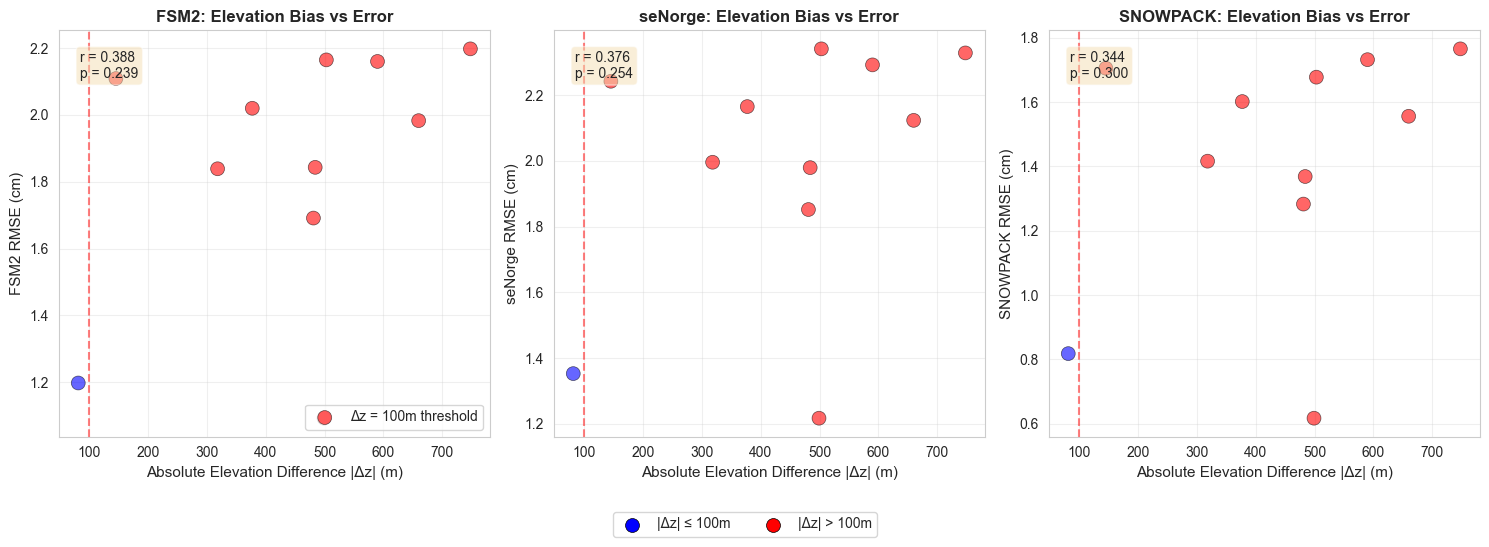

Saved: elevation_bias_vs_rmse.png


In [19]:
# Create visualization: Δz vs RMSE for each model
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['red' if x > 100 else 'blue' for x in valid_data['Abs_Delta_Z']]

for idx, model in enumerate(models):
    rmse_col = f'{model}_RMSE'
    ax = axes[idx]
    
    scatter = ax.scatter(valid_data['Abs_Delta_Z'], valid_data[rmse_col], 
                         c=colors, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
    
    # Add reference line at Δz = 100m
    ax.axvline(x=100, color='red', linestyle='--', alpha=0.5, label='Δz = 100m')
    
    # Add correlation info
    corr, p_val = stats.pearsonr(valid_data['Abs_Delta_Z'], valid_data[rmse_col])
    ax.text(0.05, 0.95, f'r = {corr:.3f}\np = {p_val:.3f}', 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Absolute Elevation Difference |Δz| (m)', fontsize=11)
    ax.set_ylabel(f'{model} RMSE (cm)', fontsize=11)
    ax.set_title(f'{model}: Elevation Bias vs Error', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    if idx == 0:
        ax.legend(['Δz = 100m threshold'], loc='lower right')

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [
    plt.scatter([], [], c='blue', s=100, edgecolors='black', linewidth=0.5, label='|Δz| ≤ 100m'),
    plt.scatter([], [], c='red', s=100, edgecolors='black', linewidth=0.5, label='|Δz| > 100m')
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=2)

plt.tight_layout()
plt.savefig('../figures_thesis/elevation_bias_vs_rmse.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: elevation_bias_vs_rmse.png")

/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_15843/3695727060.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['|Δz| ≤ 100m', '|Δz| > 100m'],
/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_15843/3695727060.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['|Δz| ≤ 100m', '|Δz| > 100m'],
/var/folders/4n/m1gxpf611c158s8wx2jzfqgw0000gn/T/ipykernel_15843/3695727060.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['|Δz| ≤ 100m', '|Δz| > 100m'],


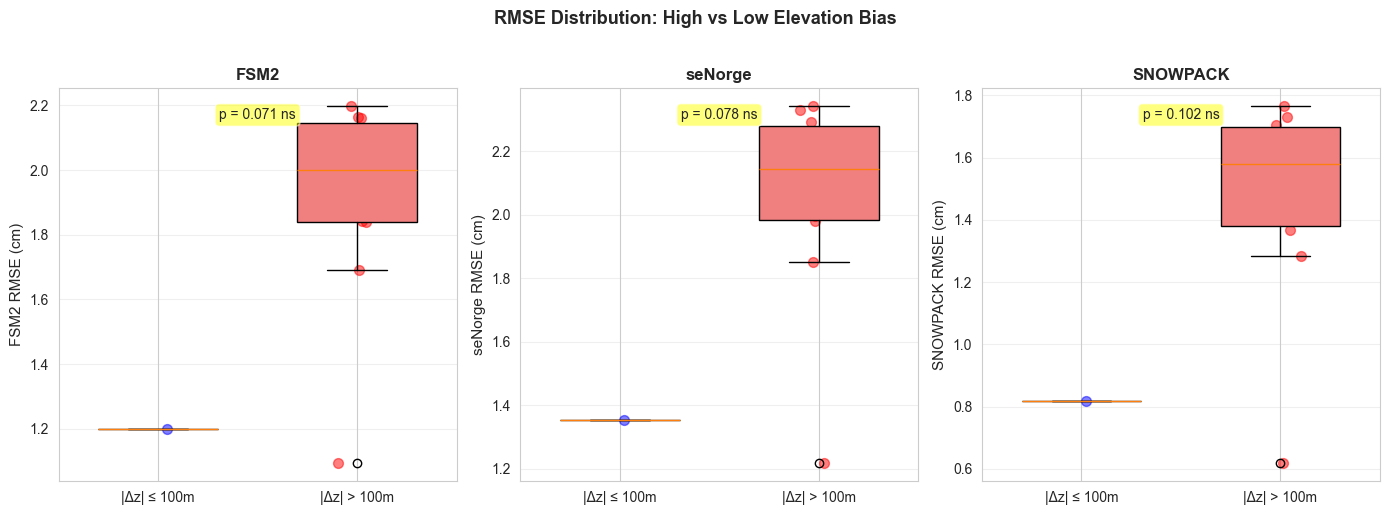

Saved: elevation_bias_boxplot.png


In [20]:
# Box plot: RMSE distribution for high vs low Δz
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for idx, model in enumerate(models):
    rmse_col = f'{model}_RMSE'
    ax = axes[idx]
    
    data_to_plot = [
        low_delta_z[rmse_col],
        high_delta_z[rmse_col]
    ]
    
    bp = ax.boxplot(data_to_plot, labels=['|Δz| ≤ 100m', '|Δz| > 100m'],
                     patch_artist=True, widths=0.6)
    
    # Color the boxes
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    # Add individual points
    y1 = low_delta_z[rmse_col].values
    y2 = high_delta_z[rmse_col].values
    x1 = np.random.normal(1, 0.04, size=len(y1))
    x2 = np.random.normal(2, 0.04, size=len(y2))
    ax.scatter(x1, y1, alpha=0.5, s=50, color='blue')
    ax.scatter(x2, y2, alpha=0.5, s=50, color='red')
    
    # Add t-test result
    t_stat, t_pval = stats.ttest_ind(high_delta_z[rmse_col], low_delta_z[rmse_col])
    sig_text = '***' if t_pval < 0.001 else '**' if t_pval < 0.01 else '*' if t_pval < 0.05 else 'ns'
    
    ax.text(0.5, 0.95, f'p = {t_pval:.3f} {sig_text}',
            transform=ax.transAxes, horizontalalignment='center', verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
    
    ax.set_ylabel(f'{model} RMSE (cm)', fontsize=11)
    ax.set_title(f'{model}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('RMSE Distribution: High vs Low Elevation Bias', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures_thesis/elevation_bias_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved: elevation_bias_boxplot.png")

## 7. Summary Table

In [21]:
# Create summary table
summary_data = []

for model in models:
    rmse_col = f'{model}_RMSE'
    
    corr, p_val = stats.pearsonr(valid_data['Abs_Delta_Z'], valid_data[rmse_col])
    
    high_mean = high_delta_z[rmse_col].mean()
    low_mean = low_delta_z[rmse_col].mean()
    diff = high_mean - low_mean
    percent = (diff / low_mean * 100) if low_mean != 0 else 0
    
    t_stat, t_pval = stats.ttest_ind(high_delta_z[rmse_col], low_delta_z[rmse_col])
    
    summary_data.append({
        'Model': model,
        'Correlation r': f"{corr:.4f}",
        'P-value': f"{p_val:.4f}",
        'Low Δz RMSE': f"{low_mean:.3f}",
        'High Δz RMSE': f"{high_mean:.3f}",
        'Difference': f"{diff:.3f}",
        'Percent Increase': f"{percent:.1f}%",
        'T-test p-value': f"{t_pval:.4f}"
    })

summary_table = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("SUMMARY TABLE")
print("="*100)
print(summary_table.to_string(index=False))

# Save summary table
summary_table.to_csv('../data/processed/elevation_bias_summary.csv', index=False)
print(f"\nSaved summary table to: ../data/processed/elevation_bias_summary.csv")


SUMMARY TABLE
   Model Correlation r P-value Low Δz RMSE High Δz RMSE Difference Percent Increase T-test p-value
    FSM2        0.3877  0.2388       1.198        1.910      0.712            59.4%         0.0713
 seNorge        0.3761  0.2542       1.352        2.054      0.702            51.9%         0.0781
SNOWPACK        0.3444  0.2997       0.818        1.472      0.654            80.0%         0.1017

Saved summary table to: ../data/processed/elevation_bias_summary.csv
